# Fine-tuning LLMs for Chronic Kidney Disease Classification and Explainability  
### A Benchmark of Traditional ML (Random Forest) and LLM (Gemma 3n)  

---

## **Abstract**

This notebook investigates the role of Large Language Models (LLMs) in predicting Chronic Kidney Disease (CKD) from structured/tabular data, comparing their performance against a traditional machine learning baseline (Random Forest). Beyond predictive accuracy, we emphasize model explainability: SHAP and LIME provide feature-based explanations for the Random Forest, while the LLM generates natural-language rationales alongside predictions. Literature in Explainable AI—particularly the survey on Rationalization for Explainable NLP—highlights a critical limitation: most XAI methods generate explanations that are not easily understood by non-experts, limiting their scalability and practical adoption in real-world decision-making. Building on this foundation, we examine whether LLM-generated rationales are *meaningful*, *faithful*, and *aligned* with classical ML explainability, aiming to bridge traditional feature attribution with accessible, text-based rationalization for healthcare applications.

--
# **1. Introduction**
Chronic Kidney Disease (CKD) prediction is an important clinical task due to its silent onset and long-term health consequences. Traditional machine learning models (e.g., Random Forests) perform well on structured clinical data and support feature-level explainability using model-agnostic techniques such as SHAP and LIME.

Modern LLMs, when fine-tuned on serialized patient records, can perform classification while also generating *self-explanatory rationales*. This notebook evaluates whether such natural-language explanations align with classical ML explanations.

---

# **2. Research Motivation**
This notebook is based on ideas from the research domain of **rationalization for explainable NLP**, where the model not only predicts an output but also provides a natural language justification.  
Our goal is to test whether a fine-tuned LLM can generate rationales that:

- mention clinically relevant features,  
- correspond to feature importance in SHAP,  
- and improve interpretability for end-users.

This creates a hybrid evaluation bridging traditional ML explainability and NLP rationalization.

---

# **3. Objectives**
1. Fine-tune an LLM on serialized CKD records to produce predictions and rationales.  
2. Train a Random Forest classifier as a classical ML baseline.  
3. Evaluate predictive performance: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC.  
4. Compare explainability using:  
   - RF feature importances, SHAP, LIME  
   - LLM-generated natural-language rationales  
5. Analyze alignment between LLM rationales and SHAP-identified important features.  
6. Provide a reproducible notebook for evaluation and future publication.

---








# **4. Workflow**

File exists: True


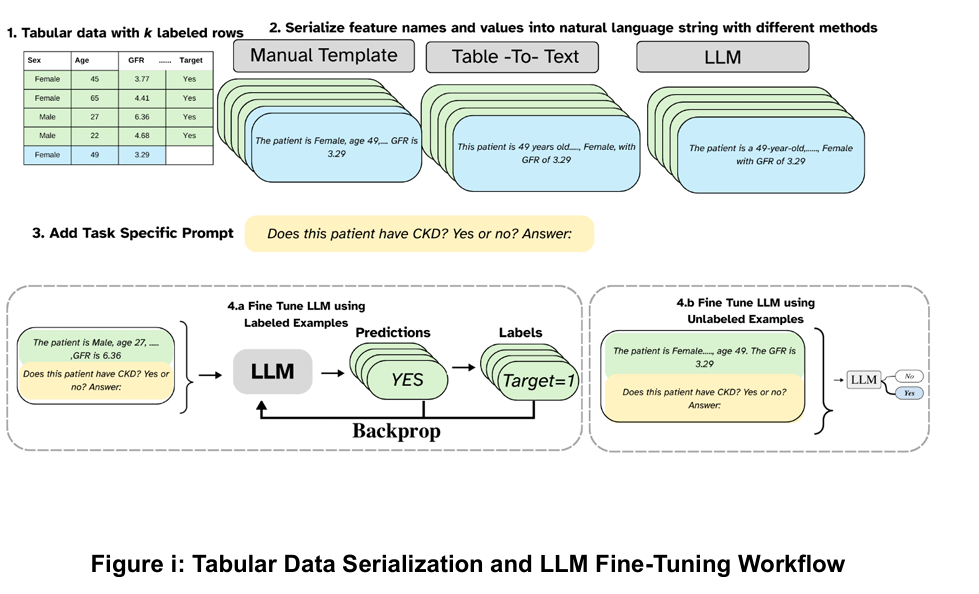

In [2]:
from IPython.display import Image, display
import os

# Verify file exists first
file_path = "/kaggle/input/image-workflow/workflow.png"
print(f"File exists: {os.path.exists(file_path)}")

# Display the image
display(Image(file_path, width=900, height=600))


## **1. Installation** 

In [3]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.55.4
!pip install --no-deps trl==0.22.2
import torch


## **2. Necessary Libraries** 

In [4]:
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score,precision_score

## **3. Model Loading :** 

In [5]:
from unsloth import FastModel
import torch

fourbit_models = [
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3n-E4B-it-unsloth-bnb-4bit",
    "unsloth/gemma-3n-E2B-it-unsloth-bnb-4bit",
    # Pretrained models
    "unsloth/gemma-3n-E4B-unsloth-bnb-4bit",
    "unsloth/gemma-3n-E2B-unsloth-bnb-4bit",

    # Other Gemma 3 quants
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3n-E4B-it", # Changed to 1b model
    dtype = None, # None for auto detection
    max_seq_length = 1024, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-01-03 14:58:53.779856: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767452333.968557      54 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767452334.027417      54 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767452334.743672      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767452334.743709      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767452334.743712      54 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.10: Fast Gemma3N patching. Transformers: 4.55.4.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3n won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/3.72G [00:00<?, ?B/s]

...

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

 We use Gemma 3N's recommended settings of `temperature = 1.0, top_p = 0.95, top_k = 64`

In [6]:
from transformers import TextStreamer
# Helper function for inference
def do_gemma_3n_inference(messages, max_new_tokens = 128):
    _ = model.generate(
        **tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True, # Must add for generation
            tokenize = True,
            return_dict = True,
            return_tensors = "pt",
        ).to("cuda"),
        max_new_tokens = max_new_tokens,
        temperature = 1.0, top_p = 0.95, top_k = 64,
        streamer = TextStreamer(tokenizer, skip_prompt = True),
    )

## **3. Data Preparation**

In [7]:
from unsloth.chat_templates import get_chat_template
from transformers import TextStreamer
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)

In [8]:
from datasets import load_dataset
data = load_dataset("csv", data_files="/kaggle/input/ckd-serialized-llms/CKD_dataset_serialized.csv")

# By default, this creates a DatasetDict with "train" split
print(data)
print(type(data))

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 398
    })
})
<class 'datasets.dataset_dict.DatasetDict'>


We now use `standardize_data_formats` to try converting datasets to the correct format for finetuning purposes!

In [9]:


dataset = data["train"].train_test_split(test_size=0.2, shuffle=True, seed=42)


In [10]:
dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 318
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 80
    })
})

In [11]:
from unsloth.chat_templates import standardize_data_formats
# Pass the 'train' split of the dataset to the function
dataset['train'] = standardize_data_formats(dataset['train'])

In [12]:
dataset["train"]

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 318
})

We now have to apply the chat template for `Gemma-3` onto the conversations, and save it to `text`. We remove the `<bos>` token using removeprefix(`'<bos>'`) since we're finetuning. The Processor will add this token before training and the model expects only one.

In [13]:
def formatting_prompts_func(examples):
   # Create conversations based on the available columns
   # Assuming instruction and input are user turns, and output is the model's response
   convos = []
   for instruction, user_input, output in zip(examples["instruction"], examples["input"], examples["output"]):
       messages = []
       # Add instruction if present
       if instruction:
           messages.append({"role": "user", "content": instruction})
       # Add input if present (assuming it's part of the user's turn or a separate user turn)
       if user_input:
           # Decide how to incorporate input - here assuming it's part of the user's turn
           if messages:
               messages[-1]["content"] += f"\n{user_input}"
           else:
               messages.append({"role": "user", "content": user_input})
       # Add model's output
       if output:
           messages.append({"role": "model", "content": output})
       convos.append(messages)

   # Apply the chat template to the created conversations
   # Ensure add_generation_prompt is False for training data
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos]

   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/318 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Let's see how the chat template did! Notice there is no `<bos>` token as the processor tokenizer will be adding one.

## **4. Finetuning Gemma 3N**


In [14]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # Should leave on always!

    r = 8,           # Larger = higher accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    TORCH_USE_CUDA_DSA=True
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


<a name="Train"></a>
###5. Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [15]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset['train'], # Specify the 'train' split
    eval_dataset = dataset['test'], # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4, # Use GA to mimic batch size!
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none", # Use this for WandB etc
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/318 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/80 [00:00<?, ? examples/s]

We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

In [16]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n",
)

Map (num_proc=8):   0%|          | 0/318 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/80 [00:00<?, ? examples/s]

Let's verify masking the instruction part is done! Let's print the 100th row again.  Notice how the sample only has a single `<bos>` as expected!

In [17]:
row_data= tokenizer.decode(trainer.train_dataset[10]["input_ids"])
row_data

'<bos><start_of_turn>user\nBased on the patient description, predict if they have CKD.\nThis patient is 76 years old, male. The age (years) is 76. The sex is male. The hemoglobin (g/dL) is 12.2. The hematocrit (%) is 38.4. The lymphocytes (%) are 11. The mean corpuscular hemoglobin (MCH, pg) is 27.8. The mean corpuscular hemoglobin concentration (MCHC, g/dL) is 34.8. The mean corpuscular volume (MCV, fL) is 80.0. The monocytes (%) are 3. The mean platelet volume (fL) is 8.4. The plateletcrit (%) is 0.2. The platelet distribution width (%) is 38.1. The platelet count (×10^9/L) is 237. The polymorphs (%) are 85. The red blood cell count (million/µL) is 4.8. The red cell distribution width (RDW-SD, fL) is 15.3. The white blood cell count (×10^9/L) is 12.6. The eosinophils (%) are 1. The serum creatinine (mg/dL) is 3.0. The blood urea (mg/dL) is 81.0. The glomerular filtration rate (mL/min/1.73m²) is 20.45.<end_of_turn>\n<start_of_turn>model\nNot CKD<end_of_turn>\n'

In [18]:


# This pattern captures all text between '<start_of_turn>user\n' and its closing '<end_of_turn>'
input_pattern = r'<start_of_turn>user\n(.+?)<end_of_turn>'
input_match = re.search(input_pattern, row_data, re.DOTALL)

if input_match:
    instruction_full = input_match.group(1).strip()
    
    # Split the content into lines (Instruction is index 0, Features is index 1)
    lines = instruction_full.splitlines()
    
    # Check if the list has at least two lines before accessing index 1
    if len(lines) >= 2:
        # A. Instruction (The main question) is the first line
        instruction_title = lines[0].strip() 
        
        # B. Features (The medical data) is the second line
        feature_data = lines[1].strip()

        
        print(f"1. Instruction: {instruction_title}")
        print(f"2. Feature Data (Start): {feature_data[:50]}...")
    else:
        print("Error: User turn does not contain expected number of lines.")
        
### 2. Extract the Classification Label (Output)

output_pattern = r'<start_of_turn>model\n(.+?)<end_of_turn>'
output_match = re.search(output_pattern, row_data, re.DOTALL)

if output_match:
    classification_label = output_match.group(1).strip()
    print(f"3. Classification Label: {classification_label}") 

1. Instruction: Based on the patient description, predict if they have CKD.
2. Feature Data (Start): This patient is 76 years old, male. The age (years...
3. Classification Label: Not CKD


Now let's print the masked out example - you should see only the answer is present:

In [19]:

tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[10]["labels"]]).replace(tokenizer.pad_token, " ")

'                                                                                                                                                                                                                                                                                                                                           Not CKD<end_of_turn>\n'

In [20]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
13.629 GB of memory reserved.


In [21]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 318 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 19,210,240 of 7,869,188,432 (0.24% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,19.577100
2,19.906000
3,8.553600
4,7.746600
5,1.800700
6,4.625500
7,3.762200
8,0.391300
9,1.749300
10,0.346300


✅ Starting data extraction from trainer.state.log_history...
📊 Generating plot...


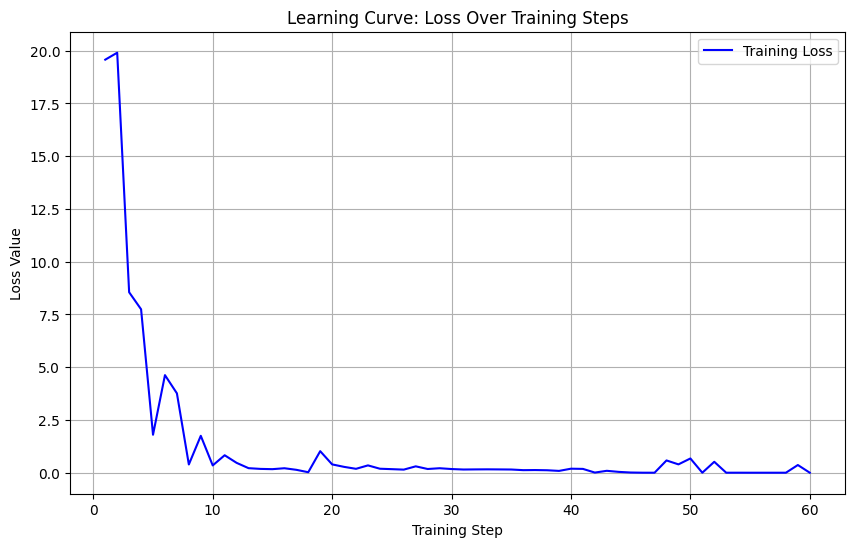


Plot generated successfully.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import Trainer, TrainingArguments # Import necessary classes

# -------------------------------------------------------------
# 1. SETUP & TRAINING (MUST BE COMPLETED FIRST)
# -------------------------------------------------------------


# 2. DATA EXTRACTION
print("✅ Starting data extraction from trainer.state.log_history...")

# Access the log history right after training
log_history = trainer.state.log_history

# Convert the history list to a DataFrame
logs_df = pd.DataFrame(log_history)

# Filter for Training Loss ('loss' column is not NaN)
train_logs = logs_df.dropna(subset=['loss'])
train_steps = train_logs['step']
train_loss = train_logs['loss']


# 3. PLOT GENERATION
print("📊 Generating plot...")

plt.figure(figsize=(10, 6))

if not train_loss.empty:
    plt.plot(train_steps, train_loss, label='Training Loss', color='blue')

# Set labels and title
plt.title('Learning Curve: Loss Over Training Steps')
plt.xlabel('Training Step')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()

print("\nPlot generated successfully.")

In [23]:
logs_df

,loss,grad_norm,learning_rate,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,19.5771,3.421897e+06,0.000000,0.012579,1,NaN,NaN,NaN,NaN,NaN
1,19.9060,inf,0.000040,0.025157,2,NaN,NaN,NaN,NaN,NaN
2,8.5536,2.255461e+04,0.000080,0.037736,3,NaN,NaN,NaN,NaN,NaN
3,7.7466,1.020690e+04,0.000120,0.050314,4,NaN,NaN,NaN,NaN,NaN
4,1.8007,5.831244e+03,0.000160,0.062893,5,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
56,0.0001,9.538438e-02,0.000015,0.716981,57,NaN,NaN,NaN,NaN,NaN
57,0.0004,6.085588e-01,0.000011,0.729560,58,NaN,NaN,NaN,NaN,NaN
58,0.3652,1.398834e+02,0.000007,0.742138,59,NaN,NaN,NaN,NaN,NaN
59,0.0001,5.564829e-02,0.000004,0.754717,60,NaN,NaN,NaN,NaN,NaN


In [24]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

320.3781 seconds used for training.
5.34 minutes used for training.
Peak reserved memory = 13.629 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 92.456 %.
Peak reserved memory for training % of max memory = 0.0 %.


<a name="Inference"></a>
## **5. Inference**
Let's run the finetuned model via Unsloth native inference! According to the `Gemma-3` team, the recommended settings for inference are `temperature = 1.0, top_p = 0.95, top_k = 64`

In [25]:
dataset['test']['input'][0]

'This patient is 39 years old, female. The age (years) is 39. The sex is female. The hemoglobin (g/dL) is 13.6. The hematocrit (%) is 37.06. The lymphocytes (%) are 29. The mean corpuscular hemoglobin (MCH, pg) is 28.0. The mean corpuscular hemoglobin concentration (MCHC, g/dL) is 36.0. The mean corpuscular volume (MCV, fL) is 78.0. The monocytes (%) are 4. The mean platelet volume (fL) is 7.0. The plateletcrit (%) is 0.2. The platelet distribution width (%) is 34.0. The platelet count (×10^9/L) is 280. The polymorphs (%) are 65. The red blood cell count (million/µL) is 4.7. The red cell distribution width (RDW-SD, fL) is 14.0. The white blood cell count (×10^9/L) is 6.8. The eosinophils (%) are 2. The serum creatinine (mg/dL) is 0.8. The blood urea (mg/dL) is 23.0. The glomerular filtration rate (mL/min/1.73m²) is 79.85.'

**FOR CKD**

In [26]:
messages = [{
    "role": "user",
    "content": [{"type" : "text", "text" : "Predict whether the patient has ckd or not with concise reason (mention range of fearures if available) if This patient is 67 years old, male. The age (years) is 67. The sex is male. The hemoglobin (g/dL) is 9.8. The hematocrit (%) is 29.0. The lymphocytes (%) are 20. The mean corpuscular hemoglobin (MCH, pg) is 27.0. The mean corpuscular hemoglobin concentration (MCHC, g/dL) is 33.0. The mean corpuscular volume (MCV, fL) is 80.0. The monocytes (%) are 7. The mean platelet volume (fL) is 9.4. The plateletcrit (%) is 0.16. The platelet distribution width (%) is 15.7. The platelet count (×10^9/L) is 175. The polymorphs (%) are 71. The red blood cell count (million/µL) is 3.6. The red cell distribution width (RDW-SD, fL) is 40.0. The white blood cell count (×10^9/L) is 6.9. The eosinophils (%) are 3. The serum creatinine (mg/dL) is 9.1. The blood urea (mg/dL) is 122.0. The glomerular filtration rate (mL/min/1.73m²) is 5.83."}]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
    tokenize = True,
    return_dict = True,
).to("cuda")

from transformers import TextStreamer
_ = model.generate(
    **inputs,
    max_new_tokens = 256, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

**Yes, the patient has CKD.**

**Reason:** The serum creatinine is significantly elevated at 9.1 mg/dL, and the glomerular filtration rate (GFR) is very low at 5.83 mL/min/1.73m². These values strongly indicate a severe decline in kidney function, consistent with Chronic Kidney Disease (CKD). The blood urea is also elevated, further supporting this diagnosis.
<end_of_turn>


**FOR NOT CKD**

In [34]:
messages = [{
    "role": "user",
    "content": [{"type" : "text", "text" : "Predict whether the patient has ckd or not with concise reason (mention range of fearures if available) if This patient is 65 years old, female. The age (years) is 65. The sex is female. The hemoglobin (g/dL) is 13.9. The hematocrit (%) is 38.9. The lymphocytes (%) are 37. The mean corpuscular hemoglobin (MCH, pg) is 25.0. The mean corpuscular hemoglobin concentration (MCHC, g/dL) is 36.0. The mean corpuscular volume (MCV, fL) is 72.0. The monocytes (%) are 2. The mean platelet volume (fL) is 10.6. The plateletcrit (%) is 0.2. The platelet distribution width (%) is 50.0. The platelet count (Ã—10^9/L) is 191. The polymorphs (%) are 59. The red blood cell count (million/ÂµL) is 5.42. The red cell distribution width (RDW-SD, fL) is 14.7. The white blood cell count (Ã—10^9/L) is 15.0. The eosinophils (%) are 2. The serum creatinine (mg/dL) is 1.1. The blood urea (mg/dL) is 56.0. The glomerular filtration rate (mL/min/1.73mÂ²) is 49.85."}]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
    tokenize = True,
    return_dict = True,
).to("cuda")

from transformers import TextStreamer
_ = model.generate(
    **inputs,
    max_new_tokens = 256, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

**No, the patient likely does not have CKD.**

**Reason:** The serum creatinine is 1.1 mg/dL and the glomerular filtration rate (GFR) is 49.85 mL/min/1.73m². These values are within the normal range, indicating adequate kidney function. 

While the white blood cell count is slightly elevated, the creatinine and GFR are the most important indicators for CKD.
<end_of_turn>


In [27]:
def generate_ckd_prediction(patient_input):
    messages = [{
        "role": "user",
        "content": [{
            "type": "text",
            "text": f"Predict whether the patient has ckd or not and i want only ckd or not ckd as output and no reasoning if {patient_input}"
        }]
    }]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        tokenize=True,
        return_dict=True,
    ).to("cuda")

    output_ids = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=1.0,
        top_p=0.95,
        top_k=64,
    )

    # Full raw decoded text with template tokens
    return tokenizer.decode(output_ids[0], skip_special_tokens=False)


def clean_output(text):
    # Split to keep only the model reply
    if "<start_of_turn>model" in text:
        text = text.split("<start_of_turn>model")[-1]

    # Remove all extra tokens
    junk = [
        "<bos>", "<start_of_turn>user", "<start_of_turn>model",
        "<end_of_turn>", "<endofturn>", "<|eot_id|>"
    ]
    for token in junk:
        text = text.replace(token, "")

    # Final clean
    return text.strip().lower()

preds = []
truths = [t.lower().strip() for t in dataset["test"]["output"]]

for i in range(80):
    raw = generate_ckd_prediction(dataset["test"]["input"][i])
    clean = clean_output(raw)
    preds.append(clean)



## **6. Metrics**

In [28]:
mapping = {
    "ckd": 1,
    "not ckd": 0
}

preds_num = [mapping[p.strip().lower()] for p in preds]
truths_num = [mapping[t.strip().lower()] for t in truths]


In [29]:
for i in range(80):
    if preds_num[i]!=truths_num[i]:
        print(f"At index{i} Prediction : {preds_num[i]},-->Actual : {truths_num[i]}")

At index3 Prediction : 1,-->Actual : 0
At index14 Prediction : 1,-->Actual : 0
At index48 Prediction : 1,-->Actual : 0
At index58 Prediction : 1,-->Actual : 0


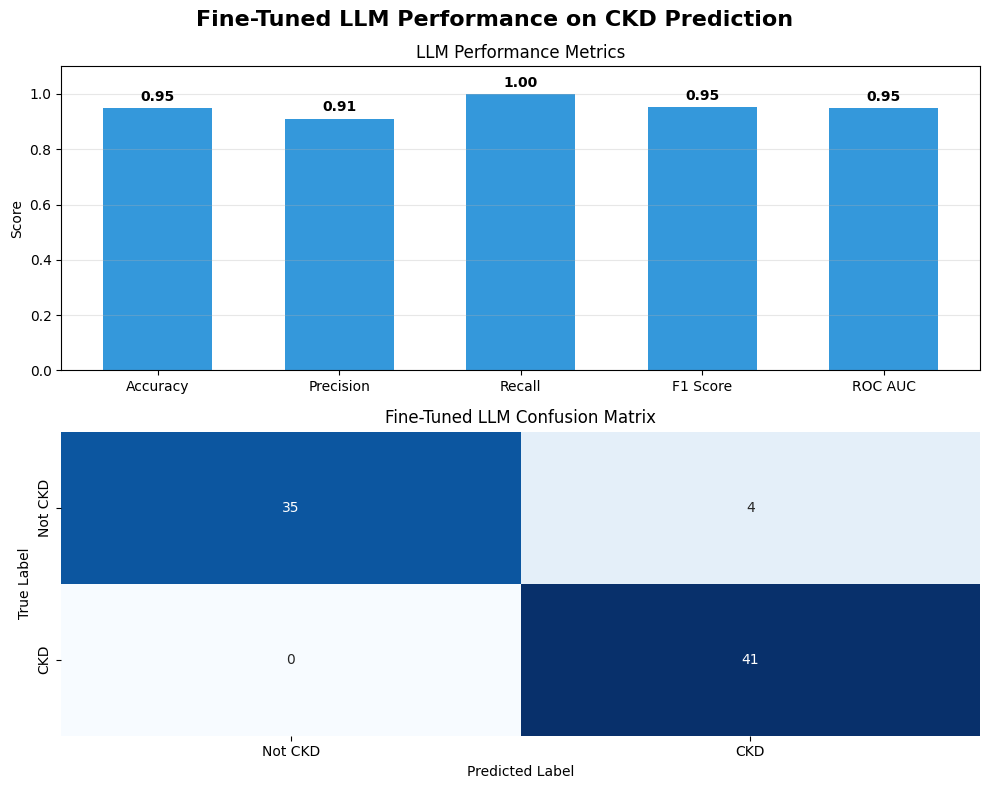

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ========================================
# 1️⃣ LLM METRICS (from your actual data)
# ========================================
llm_accuracy = accuracy_score(truths_num, preds_num)
llm_precision = precision_score(truths_num, preds_num)
llm_recall = recall_score(truths_num, preds_num)
llm_f1 = f1_score(truths_num, preds_num)
llm_auc = roc_auc_score(truths_num, preds_num)
llm_cm = confusion_matrix(truths_num, preds_num)

# ========================================
# 2️⃣ VISUALIZATION (LLM ONLY)
# ========================================
fig = plt.figure(figsize=(10, 8))
fig.suptitle(
    "Fine-Tuned LLM Performance on CKD Prediction",
    fontsize=16,
    fontweight="bold"
)

# --- Top: LLM Metrics Bar Chart ---
ax_bar = plt.subplot2grid((2, 1), (0, 0))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
llm_values = [llm_accuracy, llm_precision, llm_recall, llm_f1, llm_auc]

x = np.arange(len(metrics))

bars = ax_bar.bar(
    x,
    llm_values,
    color="#3498DB",
    width=0.6
)

ax_bar.set_ylabel("Score")
ax_bar.set_title("LLM Performance Metrics")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics)
ax_bar.set_ylim(0, 1.1)
ax_bar.grid(axis="y", alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax_bar.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# --- Bottom: LLM Confusion Matrix ---
ax_cm = plt.subplot2grid((2, 1), (1, 0))
sns.heatmap(
    llm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not CKD", "CKD"],
    yticklabels=["Not CKD", "CKD"],
    ax=ax_cm
)

ax_cm.set_title("Fine-Tuned LLM Confusion Matrix")
ax_cm.set_ylabel("True Label")
ax_cm.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()


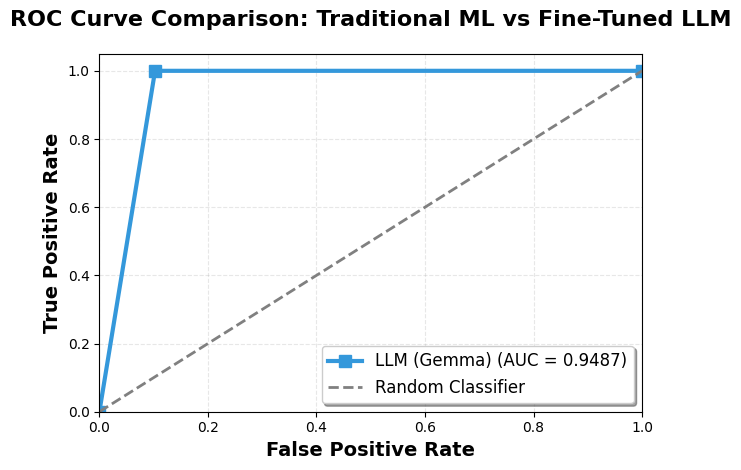

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# ========================================
# 1️⃣ LLM METRICS
# ========================================
llm_auc = roc_auc_score(truths_num, preds_num)
llm_fpr, llm_tpr, llm_thresholds = roc_curve(truths_num, preds_num)



# Plot LLM ROC curve
plt.plot(llm_fpr, llm_tpr, color='#3498DB', lw=3, 
         label=f'LLM (Gemma) (AUC = {llm_auc:.4f})', marker='s', markersize=8)

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

# Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve Comparison: Traditional ML vs Fine-Tuned LLM', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

File exists: True


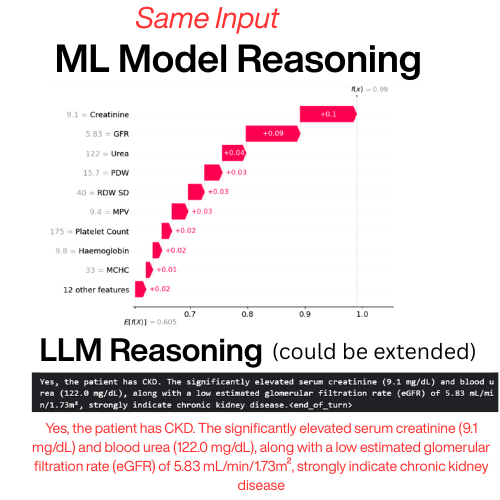

In [32]:
from IPython.display import Image, display
import os

# Verify file exists first
file_path = "/kaggle/input/explain/explain.png"
print(f"File exists: {os.path.exists(file_path)}")

# Display the image
display(Image(file_path, width=900, height=600))



<a name="Save"></a>
## **7. Saving, loading finetuned models**
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.


In [33]:
model.save_pretrained("gemma-3n_ckd_finetuned")  # Local saving
tokenizer.save_pretrained("gemma-3n_ckd_finetuned") # Local saving


['gemma-3n_ckd_finetuned/processor_config.json']